## Training demo for CNN-LSTM with custom loss function and SeismicDataLoader

In this demo, CNN-LSTM is used as the model and CustomLoss is used as the loss function.
- This demo uses train and validation dataloaders from dataloader.py. If you haven't seen dataloader_demo.ipynb, check it first.
- First, import train and validation dataloader
- Next, import custom loss function from customloss.py
- Next, we add CNN-LSTM model for demo purposes
- Next, import torch optimizer (we will use Adam, if you use other optimizers, import it)
- Then, we add matplotlib plt for traning, validation graph plotting
- Finally, add train_model function from trainer.py

In [1]:
import sys
import os
# Add the src_dataset directory to the sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src_dataset/')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../utils/')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src_model/')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src_loss/')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

from dataloader import train_dataloader, val_dataloader
from customLoss import CustomLoss
from cnn_lstm import CNN_LSTM
import torch.optim as optim
import matplotlib.pyplot as plt
from trainer import train_model, train_model_with_logging
import torch
import datetime


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


[I] Checking if the dataset is downloaded with the name afad_hfd5.zip
[S] Dataset is downloaded, loading the dataset
---------------- Dataset information: ----------------
[I] Sample rate: 100 Hz
[I] Chosen window size:900
[I] Hopping size:300
[I] Each sample is window_size/sample rate seconds long. Each sample has 3 channels.
[I] Dataset values shape is: [num_samples, num_window, num_channel, (height) 1, (width) num_sample_points]
[I] Dataset value shape: torch.Size([1575, 3, 3, 1, 900])
[I] Dataset labels shape is: [num_samples, 6], where the 6 values are [p_idx, s_idx, no_PS, only_P, only_S, both_PS]
[I] Dataset label shape:torch.Size([4725, 6])
[I] One sample shape: torch.Size([3, 3, 1, 900])
[I] One label shape: torch.Size([6])
[I] ----------------------------------------------------
[I] Some label examples in the dataset:
[I] Label: tensor([-1., -1.,  1.,  0.,  0.,  0.])
[I] Label: tensor([894.,  -1.,   0.,   1.,   0.,   0.])
[I] Label: tensor([359., 953.,   0.,   0.,   0.,   1.]

### Model setup

This below cell creates a model instance. If you'd like to use your own model, change this cell.
The example CNN-LSTM model takes the below inputs:
- input channel size
- output dimension
- hidden size of LSTM

model variable is used to keep the model

In [2]:
# Define the model
# Dynamically fetching input channels, num_windows, data_points_of_each_window, and output_dim from the dataset using the dataloader

# Create an iterator from the dataloader
train_iter = iter(train_dataloader)

# Get the first batch
one_sample = next(train_iter)  # one_sample[0].shape --> torch.Size([16, 3, 3, 1, 900]), one_sample[1].shape --> torch.Size([16, 6])

# Extract input and output dimensions
INPUT_CHANNELS = one_sample[0].shape[2]  # one_sample[0].shape[2] --> 3 (seismic channels: X, Y, Z)
NUM_WINDOWS = one_sample[0].shape[1]  # one_sample[0].shape[1] --> 3 (number of windows)
DATA_POINTS_OF_EACH_WINDOW = one_sample[0].shape[4]  # one_sample[0].shape[4] --> 900 (window size)
OUTPUT_DIM = one_sample[1].shape[1]  # one_sample[1].shape[1] --> 6 (label dimensions)

# Model hyperparameters
HIDDEN_DIM = 256  # Hidden size for LSTM
print("Input Channels: ", INPUT_CHANNELS)
print("Output Dim: ", OUTPUT_DIM)
print("Num Windows: ", NUM_WINDOWS)
print("Data Points of Each Window: ", DATA_POINTS_OF_EACH_WINDOW)

# Instantiate the CNN_LSTM model
model = CNN_LSTM(
    input_channels=INPUT_CHANNELS,
    hidden_size=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
)

# Move the model to the appropriate device
model = model.to(device)

# Print the model architecture
print(model)

Input Channels:  3
Output Dim:  6
Num Windows:  3
Data Points of Each Window:  900
CNN_LSTM(
  (encoder): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(3,))
    (13): BatchNorm1d(256, eps=1e

### Training the model
We have been created dataloaders and model. Now we will train the model with generic train function.
- First, initialize optimizer. In this demo, Adam optimizer is used with lr = LEARNING_RATE.
- Next, set the loss function as criterion. In this demo, CustomLoss function with lambda_val = CUSTOM_LOSS_LAMBDA is used.
- Then, set the number of epochs.
- Next, train the model. train_model function trains the model with train_dataloader, and validates after each epoch with val_dataloader

In [3]:
LEARNING_RATE = 0.002
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Train the model
CUSTOM_LOSS_LAMBDA = 0.7
criterion = CustomLoss(lambda_val=CUSTOM_LOSS_LAMBDA)
num_epochs = 1000
train_log_file= 'cnn_lstm'

model, train_losses, val_losses = train_model_with_logging(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    early_stopping=True  # Optional: Enable early stopping if required
)
print('Training completed.')

C:\ProgramData\anaconda3\Lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/999, Training Loss: 275644.6900
Validation Loss: 257033.9831
Epoch 1/999, Training Loss: 263666.4885
Validation Loss: 245462.6202
Epoch 2/999, Training Loss: 252335.4688
Validation Loss: 234481.9261
Epoch 3/999, Training Loss: 241623.9748
Validation Loss: 223984.2283
Epoch 4/999, Training Loss: 231432.9158
Validation Loss: 214145.0973
Epoch 5/999, Training Loss: 221686.1549
Validation Loss: 204684.3026
Epoch 6/999, Training Loss: 212297.5707
Validation Loss: 195646.2408
Epoch 7/999, Training Loss: 203217.9322
Validation Loss: 186756.0398
Epoch 8/999, Training Loss: 194440.7873
Validation Loss: 178262.3768
Epoch 9/999, Training Loss: 186114.1620
Validation Loss: 170123.0383
Epoch 10/999, Training Loss: 178122.9091
Validation Loss: 162381.6370
Epoch 11/999, Training Loss: 170524.4564
Validation Loss: 155100.3734
Epoch 12/999, Training Loss: 163234.3012
Validation Loss: 148033.2631
Epoch 13/999, Training Loss: 156192.6370
Validation Loss: 141494.4428
Epoch 14/999, Training Loss: 1

Model saved at:  models/model_20241129-0104_epoch1000_lr0.002_lambda0.7_windows3_datapoints900.pth


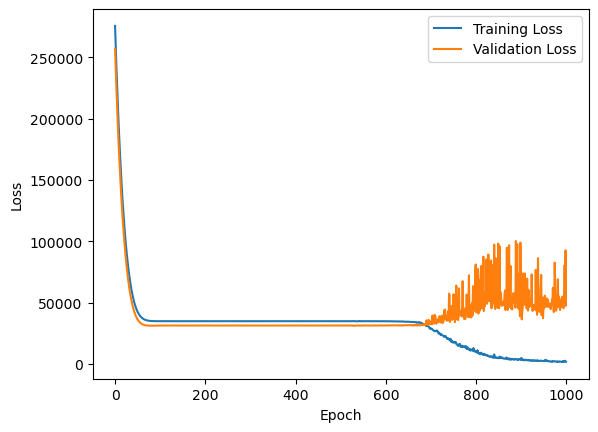

<Figure size 640x480 with 0 Axes>

Loss plot saved at: models/Train_and_val_loss_20241129-0104.png


In [4]:
import os
import time
import torch

os.makedirs('models', exist_ok=True)
date_time_str = time.strftime("%Y%m%d-%H%M")
model_name = 'models/model_{}_epoch{}_lr{}_lambda{}_windows{}_datapoints{}.pth'.format(date_time_str, num_epochs, LEARNING_RATE, CUSTOM_LOSS_LAMBDA, NUM_WINDOWS, DATA_POINTS_OF_EACH_WINDOW)
torch.save(model.state_dict(), model_name)
print('Model saved at: ', model_name)

# plot and save the training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('models/Train_and_val_loss_model_{}'.format(model_name.split('/')[1].split('.')[0]))
plt.show()

# Save the loss plot
loss_plot_name = f'models/Train_and_val_loss_{date_time_str}.png'
plt.savefig(loss_plot_name)
plt.show()

print(f'Loss plot saved at: {loss_plot_name}')